In [2]:
import json
from typing import Any, Literal
from typing_extensions import TypedDict

from fastapi import HTTPException, status

from sqlalchemy import select
from sqlalchemy.orm import Session

from langgraph.graph import StateGraph, START, END

from app.core.config import settings
from app.core.llm import get_assistant_llm
from app.models.mention import Mention
from app.models.resolution_result import ResolutionResult

from app.models.enums import ResolutionDecision, ResolutionStatus
from app.schemas.assistant import AssistantRecommendation

from app.services.candidate_service import CandidateService
from app.clients.document_client import DocumentClient


# ==========================================================
# GRAPH STATE
# ==========================================================

class ResolutionAssistantState(TypedDict, total=False):  # total=False means all fields are optional.

    # Inputs
    session: Session
    mention_id: int
    max_candidates: int

    # Loaded data
    mention: Mention
    candidates: list[dict]
    candidate_payload: list[dict]

    # Candidate analysis
    ambiguous: bool
    score_gap: float | None
    route: str

    # LLM recommendation
    recommendation: (AssistantRecommendation | None)
    recommended_business_id: (int | None)

    # Final validated decision
    final_action: Literal["resolve", "escalate"]

    selected_business_id: (int | None)
    assistant_confidence: (float | None)
    decision_source: Literal["rule", "policy", "llm"]

    note: str
    document_id: int | None
    workflow_steps: list[str]
    response: dict



# ==========================================================
# HELPER
# ==========================================================

def add_step(state: ResolutionAssistantState, step: str) -> list[str]:

    return [
        *state.get("workflow_steps", []),
        step,
    ]


# ==========================================================
# NODE 1
# LOAD MENTION
# ==========================================================

def load_mention_node(state: ResolutionAssistantState) -> dict:

    session = state["session"]

    mention_id = state["mention_id"]

    mention = (
        session.execute(
            select(Mention).where(Mention.id == mention_id)
        ).scalar_one_or_none()
    )

    if mention is None:

        raise HTTPException(
            status_code=status.HTTP_404_NOT_FOUND,
            detail="Mention not found",
        )

    if not mention.text or not mention.text.strip():

        raise HTTPException(
            status_code=status.HTTP_422_UNPROCESSABLE_ENTITY,
            detail=(
                "Mention text cannot be empty."
            ),
        )

    # The assistant works only on new,
    # unprocessed mentions.
    if mention.resolution_status != ResolutionStatus.PENDING:

        raise HTTPException(
            status_code=status.HTTP_409_CONFLICT,
            detail=(
                "Mention has already gone "
                "through resolution."
            ),
        )

    # Make sure there aren't old candidate
    # records connected to a pending mention.
    existing_result = (
        session.execute(
            select(ResolutionResult.id).where(ResolutionResult.mention_id == mention.id).limit(1)
        ).scalar_one_or_none()
    )

    if existing_result is not None:

        raise HTTPException(
            status_code=status.HTTP_409_CONFLICT,
            detail=(
                "This pending mention already "
                "has resolution results."
            ),
        )

    return {
        "mention": mention,
        "workflow_steps": add_step(state, "Loaded pending mention and source context."),
    }


# ==========================================================
# NODE 2
# GENERATE CANDIDATES
# ==========================================================

def generate_candidates_node(state: ResolutionAssistantState) -> dict:

    session = state["session"]
    mention = state["mention"]
    max_candidates = state["max_candidates"]

    candidates = (
        CandidateService.get_candidates(session=session, mention=mention, max_candidates=max_candidates)
    )

    if not candidates:

        # Your current ResolutionResult model requires
        # a business_id, so there is no clean candidate
        # row we can create for a "zero candidates"
        # review case.
        #
        # For now keep the mention untouched.
        raise HTTPException(
            status_code=status.HTTP_404_NOT_FOUND,
            detail=(
                "No candidate businesses were "
                "found for this mention."
            ),
        )

    candidate_payload = []

    for candidate in candidates:

        business = candidate["business"]

        categories = []

        # Session is still open, so the relationship
        # can be loaded here.
        if business.categories:

            categories = [category.name for category in business.categories]

        candidate_payload.append(
            {
                "business_id": business.id,
                "catalog_business_id": business.business_id,
                "business_name": business.name,
                "city": business.city,
                "state": business.state,
                "address": business.address,
                "categories": categories,
                "is_verified": business.is_verified,
                "score": candidate["score"],
                "name_score": candidate["name_score"],
                "embedding_score": (
                    candidate.get("embedding_score")
                ),
                "city_score": candidate["city_score"],
                "state_score": candidate["state_score"],
                "address_score": candidate["address_score"],
            }
        )

    return {
        "candidates": candidates,

        "candidate_payload": (
            candidate_payload
        ),

        "workflow_steps": add_step(
            state,
            (
                "Generated and scored "
                "candidate businesses."
            ),
        ),
    }


# ==========================================================
# NODE 3
# ASSESS CANDIDATE QUALITY
# ==========================================================

def assess_candidates_node(
    state: ResolutionAssistantState,
) -> dict:

    candidates = state["candidates"]
    best_candidate = candidates[0]

    best_business = (
        best_candidate["business"]
    )

    best_score = float(
        best_candidate["score"]
    )

    ambiguous = False
    score_gap = None

    if len(candidates) >= 2:

        second_score = float(candidates[1]["score"])

        score_gap = round(best_score - second_score, 4)

        ambiguous = (score_gap < CandidateService.AMBIGUITY_GAP)

    # ------------------------------------------------------
    # Policy 1:
    #
    # Unverified top match must ALWAYS go for review.
    # ------------------------------------------------------

    if not best_business.is_verified:

        route = "forced_review"

    # ------------------------------------------------------
    # Policy 2:
    #
    # Already obvious, verified, non-ambiguous match.
    # No need to spend an LLM call.
    # ------------------------------------------------------

    elif best_score >= CandidateService.AUTO_RESOLUTION_THRESHOLD  and not ambiguous:

        route = "direct_resolve"

    # ------------------------------------------------------
    # Otherwise use the smart assistant.
    # ------------------------------------------------------

    else:

        route = "llm_analysis"

    return {
        "ambiguous": ambiguous,
        "score_gap": score_gap,
        "route": route,
        "workflow_steps": add_step(
            state,
            (
                "Checked candidate confidence, "
                "ambiguity and verification."
            ),
        ),
    }


# ==========================================================
# CONDITIONAL ROUTER
# ==========================================================

def route_after_assessment(state: ResolutionAssistantState) -> str:

    return state["route"]


# ==========================================================
# NODE 4A
# POLICY FORCED REVIEW
# ==========================================================

def forced_review_node(state: ResolutionAssistantState) -> dict:

    top = state["candidate_payload"][0]

    note = (
        "Sent for review because the highest "
        "ranked candidate is unverified. "
        "Project policy does not allow an "
        "unverified business to be resolved "
        "automatically."
    )

    return {
        "final_action": "escalate",
        "selected_business_id": None,
        "recommended_business_id": (
            top["business_id"]
        ),
        "assistant_confidence": None,
        "decision_source": "policy",
        "note": note,
        "workflow_steps": add_step(
            state,
            (
                "Applied mandatory unverified-"
                "business review policy."
            ),
        ),
    }


# ==========================================================
# NODE 4B
# OBVIOUS MATCH
# ==========================================================

def direct_resolve_node(state: ResolutionAssistantState) -> dict:

    top = state["candidate_payload"][0]

    note = (
        "Smart assistant resolved the mention "
        f"to '{top['business_name']}' because "
        "the candidate passed the normal "
        "automatic-resolution threshold, "
        "was verified, and was not ambiguous."
    )

    return {
        "final_action": "resolve",
        "selected_business_id": (
            top["business_id"]
        ),
        "recommended_business_id": (
            top["business_id"]
        ),
        "assistant_confidence": (
            top["score"]
        ),
        "decision_source": "rule",
        "note": note,
        "workflow_steps": add_step(
            state,
            (
                "Used deterministic rules for "
                "an obvious verified match."
            ),
        ),
    }


# ==========================================================
# NODE 4C
# LLM CONTEXT ANALYSIS
# ==========================================================

def analyze_context_node(state: ResolutionAssistantState) -> dict:

    mention = state["mention"]
    candidate_payload = state["candidate_payload"]

    try:

        llm = get_assistant_llm()

        structured_llm = (
            llm.with_structured_output(AssistantRecommendation, method="json_schema")
        )

        system_prompt = """
You are the decision-support component of a local
business mention resolution system.

Your job is to inspect ONE extracted business mention,
its surrounding source text, and ONLY the candidate
businesses supplied to you.

You must decide whether there is enough evidence to
resolve the mention to one candidate or whether it must
be escalated for human review.

IMPORTANT RULES:

1. Use only the supplied mention, source text and
   candidate records.

2. Do not use outside knowledge about a business.

3. Never invent an address, city, state or business.

4. If you choose "resolve", selected_business_id MUST
   be the database business_id from one supplied
   candidate.

5. Never resolve to an unverified candidate.
   An unverified candidate must be escalated.

6. Prefer evidence from surrounding context such as:
   - city
   - state
   - address
   - business name
   - category
   - location wording

7. Similar scores alone are NOT enough reason to guess.

8. When two candidates remain plausible and context
   does not clearly distinguish them, escalate.

9. confidence means your confidence in YOUR decision,
   from 0 to 1.

10. Write a short note explaining the evidence behind
    the decision.

11. Accuracy is more important than forcing a match.
"""

        input_data = {
            "mention": {
                "text": mention.text,
                "source_text": mention.source_text,
                "source_id": mention.source_id,
            },

            "candidate_ambiguity": {
                "ambiguous": state["ambiguous"],
                "score_gap": state["score_gap"],
            },

            "candidates": (
                candidate_payload
            ),
        }

        recommendation = (
            structured_llm.invoke(
                [
                    (
                        "system",
                        system_prompt,
                    ),
                    (
                        "human",
                        json.dumps(input_data, ensure_ascii=False, default=str),
                    ),
                ]
            )
        )

    except Exception as exc:

        # Important:
        #
        # Do NOT change database state if the
        # LLM itself failed.
        raise HTTPException(
            status_code=status.HTTP_503_SERVICE_UNAVAILABLE,
            detail=(
                "Smart assistant analysis "
                "is currently unavailable."
            ),
        ) from exc

    return {
        "recommendation": recommendation,
        "recommended_business_id": recommendation.selected_business_id,
        "workflow_steps": add_step(
            state,
            (
                "Analyzed surrounding context "
                "and candidates with the LLM."
            ),
        ),
    }


# ==========================================================
# NODE 5
# VALIDATE LLM RECOMMENDATION
# ==========================================================

def validate_recommendation_node(state: ResolutionAssistantState) -> dict:

    recommendation = state["recommendation"]
    candidates = state["candidate_payload"]
    candidate_map = {
        candidate["business_id"]: candidate for candidate in candidates
    }

    # ------------------------------------------------------
    # LLM itself decided to escalate
    # ------------------------------------------------------

    if recommendation.action == "escalate":

        return {
            "final_action": "escalate",
            "selected_business_id": None,
            "assistant_confidence": recommendation.confidence,
            "decision_source": "llm",
            "note": recommendation.note,
            "workflow_steps": add_step(
                state,
                (
                    "Validated LLM decision "
                    "to escalate."
                ),
            ),
        }

    # ------------------------------------------------------
    # LLM wants to resolve
    # ------------------------------------------------------

    selected_id = recommendation.selected_business_id

    selected_candidate = (
        candidate_map.get(selected_id) if selected_id is not None else None
    )

    # ------------------------------------------------------
    # Safety check:
    # candidate must actually exist.
    # ------------------------------------------------------

    if selected_candidate is None:

        return {
            "final_action": "escalate",
            "selected_business_id": None,
            "assistant_confidence": recommendation.confidence,
            "decision_source": "llm",

            "note": (
                "Sent for review because the "
                "assistant recommendation did "
                "not reference a valid candidate."
            ),

            "workflow_steps": add_step(
                state,
                (
                    "Rejected an invalid LLM "
                    "candidate selection."
                ),
            ),
        }

    # ------------------------------------------------------
    # Safety check:
    # unverified business.
    # ------------------------------------------------------

    if not selected_candidate["is_verified"]:

        return {
            "final_action": "escalate",
            "selected_business_id": None,
            "assistant_confidence": recommendation.confidence,
            "decision_source": "policy",
            "note": (
                "Sent for review because the "
                "assistant selected an "
                "unverified business."
            ),

            "workflow_steps": add_step(
                state,
                (
                    "Blocked automatic resolution "
                    "to an unverified candidate."
                ),
            ),
        }

    # ------------------------------------------------------
    # Safety check:
    # LLM confidence
    # ------------------------------------------------------

    if recommendation.confidence < settings.ASSISTANT_LLM_CONFIDENCE_THRESHOLD:

        return {
            "final_action": "escalate",
            "selected_business_id": None,
            "assistant_confidence": recommendation.confidence,
            "decision_source": "llm",

            "note": (
                "Sent for review because the "
                "assistant was not confident "
                "enough to resolve automatically. "
                f"Assistant note: "
                f"{recommendation.note}"
            ),

            "workflow_steps": add_step(
                state,
                (
                    "Applied assistant confidence "
                    "safety threshold."
                ),
            ),
        }

    # ------------------------------------------------------
    # Safety check:
    # underlying algorithm score
    # ------------------------------------------------------

    if selected_candidate["score"] < settings.ASSISTANT_MIN_CANDIDATE_SCORE:

        return {
            "final_action": "escalate",
            "selected_business_id": None,
            "assistant_confidence": recommendation.confidence,
            "decision_source": "llm",

            "note": (
                "Sent for review because the "
                "underlying candidate score was "
                "too low for safe automatic "
                "resolution. "
                f"Assistant note: "
                f"{recommendation.note}"
            ),

            "workflow_steps": add_step(
                state,
                (
                    "Applied minimum candidate "
                    "score safety threshold."
                ),
            ),
        }

    # ------------------------------------------------------
    # Safe to resolve
    # ------------------------------------------------------

    return {
        "final_action": "resolve",
        "selected_business_id": selected_candidate["business_id"],
        "assistant_confidence": recommendation.confidence,
        "decision_source": "llm",

        "note": (
            recommendation.note
        ),

        "workflow_steps": add_step(
            state,
            (
                "Validated assistant recommendation "
                "against deterministic safety rules."
            ),
        ),
    }


# ==========================================================
# HELPER
# FIND CANDIDATE
# ==========================================================

def find_candidate(state: ResolutionAssistantState,business_id: int) -> dict | None:

    for candidate in state["candidate_payload"]:

        if candidate["business_id"] == business_id:
            return candidate

    return None


# ==========================================================
# NODE 6
# PERSIST FINAL DECISION
# ==========================================================

def persist_decision_node(state: ResolutionAssistantState) -> dict:

    session = state["session"]
    mention = state["mention"]
    candidates = state["candidates"]
    candidate_payload = state["candidate_payload"]
    final_action = state["final_action"]
    note = state["note"]

    selected_business_id = state.get("selected_business_id")

    recommended_business_id = state.get("recommended_business_id")

    document_id = None
    selected_candidate = None

    # ======================================================
    # RESOLVE
    # ======================================================

    if final_action == "resolve":

        if selected_business_id is None:

            raise HTTPException(
                status_code=status.HTTP_500_INTERNAL_SERVER_ERROR,
                detail=(
                    "Assistant resolution has no "
                    "selected business."
                ),
            )

        selected_candidate = (
            find_candidate(state, selected_business_id)
        )

        if selected_candidate is None:

            raise HTTPException(
                status_code=status.HTTP_500_INTERNAL_SERVER_ERROR,
                detail=(
                    "Selected candidate could "
                    "not be found."
                ),
            )

        mention.resolution_status = ResolutionStatus.AUTO_RESOLVED

        mention.resolved_business_id = selected_business_id

        # Keep this field consistent with the rest
        # of your project: it stores the candidate
        # matching score.
        mention.confidence_score = selected_candidate["score"]

        for candidate in candidates:

            business = candidate["business"]

            if business.id == selected_business_id:
                decision = ResolutionDecision.AUTO
                candidate_note = (
                    "Smart assistant resolution: "
                    + note
                )

            else:

                # Keep behavior compatible with your
                # existing ResolutionService.
                decision = ResolutionDecision.REVIEW

                candidate_note = (
                    "Candidate considered during "
                    "smart assistant resolution "
                    "but not selected."
                )

            session.add(
                ResolutionResult(
                    mention_id=mention.id,
                    business_id=business.id,
                    score=candidate["score"],
                    decision=decision,
                    notes=candidate_note,
                )
            )

    # ======================================================
    # ESCALATE
    # ======================================================

    else:

        primary_business_id = (
            recommended_business_id or candidate_payload[0]["business_id"]
        )

        primary_candidate = (
            find_candidate(state, primary_business_id)
        )

        if primary_candidate is None:

            primary_candidate = candidate_payload[0]

            primary_business_id = primary_candidate["business_id"]

        mention.resolution_status = ResolutionStatus.SENT_FOR_REVIEWER
        mention.resolved_business_id = None
        mention.confidence_score = primary_candidate["score"]

        for candidate in candidates:

            business = candidate["business"]

            if business.id == primary_business_id:

                candidate_note = (
                    "Sent for review because "
                    "the smart assistant escalated "
                    "the mention. "
                    f"Reason: {note}"
                )

            else:

                candidate_note = (
                    "Candidate generated during "
                    "smart assistant review."
                )

            session.add(
                ResolutionResult(
                    mention_id=mention.id,
                    business_id=business.id,
                    score=candidate["score"],
                    decision=(
                        ResolutionDecision.REVIEW
                    ),
                    notes=candidate_note,
                )
            )

    # ======================================================
    # COMMIT
    # ======================================================

    try:

        session.commit()

        session.refresh(
            mention
        )

    except Exception:

        session.rollback()

        raise

    # ======================================================
    # CREATE RESOLUTION SUMMARY
    # ======================================================

    if mention.resolution_status == ResolutionStatus.AUTO_RESOLVED:
        document_id = (
            DocumentClient.generate_resolution_summary(mention_id=mention.id)
        )


    # ======================================================
    # RESPONSE
    # ======================================================

    selected_score = None

    if selected_business_id:

        selected_candidate = find_candidate(state, selected_business_id)

        if selected_candidate:

            selected_score = selected_candidate["score"]

    workflow_steps = add_step(
        state,
        (
            "Saved final assistant decision "
            "to the database."
        ),
    )

    if document_id is not None:

        workflow_steps = [
            *workflow_steps,
            (
                "Generated resolution "
                "summary document."
            ),
        ]

    response = {
        "mention_id": mention.id,
        "mention_text": mention.text,
        "action": "resolved" if final_action == "resolve" else "escalated" ,
        "decision_source": state["decision_source"],
        "resolution_status": mention.resolution_status.value,
        "resolved_business_id": mention.resolved_business_id,
        "recommended_business_id": recommended_business_id,
        "candidate_score": selected_score if final_action == "resolve" else mention.confidence_score,
        "assistant_confidence": state.get("assistant_confidence"),
        "ambiguous": state["ambiguous"],
        "score_gap": state.get("score_gap"),
        "note": note,
        "document_id": document_id,
        "workflow_steps": workflow_steps,
        "candidates": (
            candidate_payload
        ),
    }

    return {
        "document_id": document_id,
        "workflow_steps": workflow_steps,
        "response": response
    }


# ==========================================================
# BUILD LANGGRAPH
# ==========================================================

workflow = StateGraph(ResolutionAssistantState)


workflow.add_node("load_mention", load_mention_node)
workflow.add_node("generate_candidates",generate_candidates_node)
workflow.add_node("assess_candidates", assess_candidates_node)
workflow.add_node("forced_review", forced_review_node)
workflow.add_node("direct_resolve", direct_resolve_node)
workflow.add_node("analyze_context", analyze_context_node)
workflow.add_node("validate_recommendation", validate_recommendation_node)
workflow.add_node("persist_decision", persist_decision_node)


# START
workflow.add_edge(START,"load_mention")
workflow.add_edge("load_mention","generate_candidates")
workflow.add_edge("generate_candidates", "assess_candidates")

# ==========================================================
# CONDITIONAL DECISION
# ==========================================================

workflow.add_conditional_edges("assess_candidates",
    route_after_assessment,
    {
        "forced_review": "forced_review",
        "direct_resolve": "direct_resolve",
        "llm_analysis": "analyze_context",
    },
)


workflow.add_edge("forced_review", "persist_decision")
workflow.add_edge("direct_resolve","persist_decision")
workflow.add_edge("analyze_context","validate_recommendation")
workflow.add_edge("validate_recommendation","persist_decision")
workflow.add_edge("persist_decision", END)


# ==========================================================
# COMPILED GRAPH
# ==========================================================

resolution_assistant_graph = workflow.compile()

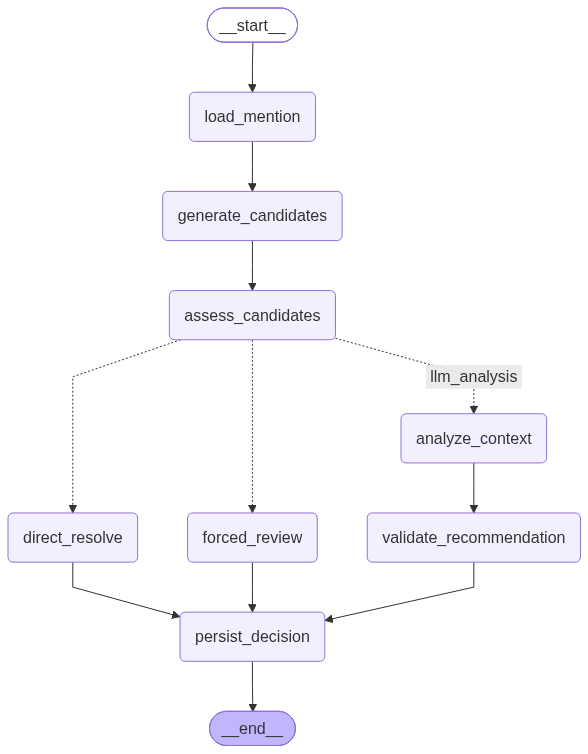

In [3]:
resolution_assistant_graph